# Realistic Soft Improvements

This notebook documents the **realism-aware improvement search** on top of the baseline + ML soft-sizing path.

Scope:
- realistic execution assumptions are already enabled:
  - next-bar-open execution
  - minute-aware stop monitoring
  - spread proxy
- the search here tests three mechanism families:
  - hybrid stop redesign
  - execution-aware relative entry control
  - intraday risk downsize overlay

Important interpretation:
- the methods here are notebook-level realism experiments on top of the current realistic assumptions;
- they are not all exposed as the default CLI surface;
- use this notebook to understand which mechanism improved the realistic path and why.


## Method Definitions

- `baseline`
  - realistic baseline only
  - same signal logic, no ML sizing

- `soft_base`
  - realistic baseline + ML soft sizing
  - label mode: `baseline_trade`
  - this is the realistic reference ML overlay

- `soft_hybrid_5`, `soft_hybrid_7_5`, `soft_hybrid_10`, `soft_hybrid_12_5`, `soft_hybrid_15`
  - same as `soft_base`
  - but stop handling changes:
    - between decision timestamps, only catastrophic minute breaches force an exit
    - at decision timestamps, the standard stop is still checked normally
  - the suffix is the catastrophic overshoot threshold in basis points

- `soft_relative_entry`
  - same as `soft_base`
  - but entries are downsized when the executable price drifts adversely relative to local band width / recent intraday volatility

- `soft_relative_hybrid_10`
  - combines the relative-entry rule with the hybrid stop using `10 bps`

- `soft_risk_q80_m75`
  - realistic soft sizing with an intraday-risk overlay that downsizes when current intraday volatility is above the recent 80th percentile

Interpretation principle:
- if a method improves Sharpe and equity mainly by lowering turnover and trade count, it is not creating new alpha; it is preserving existing alpha by avoiding unnecessary churn.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

INITIAL_AUM = 100000.0
REPO = Path('/Users/ulianahusak/WUTIS_2026/intraday_momentum_ml')
REPORTS = REPO / 'reports' / 'model_selection'
PLOTS = REPORTS / 'plots'
CURVES = REPORTS / 'realistic_soft_curves'
PLOTS.mkdir(parents=True, exist_ok=True)
CURVES.mkdir(parents=True, exist_ok=True)

summary_path = REPORTS / 'realistic_soft_refined_search_best_compare.csv'
splits_path = REPORTS / 'realistic_soft_refined_search_splits.csv'
small_path = REPORTS / 'realistic_soft_improvement_search_small.csv'

summary = pd.read_csv(summary_path)
splits = pd.read_csv(splits_path)
small = pd.read_csv(small_path) if small_path.exists() else pd.DataFrame()
summary['total_return_pct'] = (summary['final_equity'] / INITIAL_AUM - 1.0) * 100.0
if not small.empty and 'final_equity' in small.columns:
    small['total_return_pct'] = (small['final_equity'] / INITIAL_AUM - 1.0) * 100.0

curve_methods = ['baseline', 'soft_base', 'soft_hybrid_7_5', 'soft_hybrid_10', 'soft_relative_hybrid_10']
curve_frames = []
for method in curve_methods:
    path = CURVES / f'{method}_equity_curve.parquet'
    if path.exists():
        df = pd.read_parquet(path).copy()
        df['date'] = pd.to_datetime(df['date'])
        df['method'] = method
        if 'daily_return' not in df.columns and 'equity' in df.columns:
            df = df.sort_values('date')
            df['daily_return'] = df['equity'].pct_change().fillna(0.0)
        curve_frames.append(df)

curve_df = pd.concat(curve_frames, ignore_index=True) if curve_frames else pd.DataFrame()
summary


,method,sharpe,cagr_ish,max_drawdown,n_days,final_equity,trades_count,turnover,total_costs,variant
0,soft_hybrid_7_5,0.909068,0.231743,-0.221610,690.0,176950.740834,765,4917.655661,5927.850,soft_hybrid_7_5
1,soft_hybrid_10,0.870794,0.220363,-0.255491,690.0,172510.459918,731,4712.452856,5734.566,soft_hybrid_10
2,soft_hybrid_5,0.801717,0.193467,-0.198020,690.0,162298.458515,825,5298.685501,6150.798,soft_hybrid_5
3,soft_hybrid_12_5,0.775734,0.190876,-0.240958,690.0,161335.626858,709,4567.851301,5345.235,soft_hybrid_12_5
4,soft_hybrid_15,0.761620,0.185889,-0.227517,690.0,159492.327203,700,4500.372963,5190.381,soft_hybrid_15
5,soft_relative_hybrid_10,0.637429,0.091404,-0.167306,690.0,127059.756458,731,3677.749832,3728.898,soft_relative_hybrid_10
6,soft_base,0.383525,0.070144,-0.202688,690.0,120396.904439,1049,6875.154542,6454.170,soft_base
7,soft_relative_entry,-0.021217,-0.014545,-0.178555,690.0,96067.668734,1049,5344.460836,4584.699,soft_relative_entry
8,baseline,-0.171875,-0.031200,-0.187587,690.0,91686.893773,1049,6068.779522,5160.231,baseline


In [2]:
metric_cols = ['method', 'final_equity', 'total_return_pct', 'sharpe', 'max_drawdown', 'trades_count', 'turnover', 'total_costs']
metrics = summary[metric_cols].copy()
metrics


,method,final_equity,sharpe,max_drawdown,trades_count,turnover,total_costs
0,soft_hybrid_7_5,176950.740834,0.909068,-0.221610,765,4917.655661,5927.850
1,soft_hybrid_10,172510.459918,0.870794,-0.255491,731,4712.452856,5734.566
2,soft_hybrid_5,162298.458515,0.801717,-0.198020,825,5298.685501,6150.798
3,soft_hybrid_12_5,161335.626858,0.775734,-0.240958,709,4567.851301,5345.235
4,soft_hybrid_15,159492.327203,0.761620,-0.227517,700,4500.372963,5190.381
5,soft_relative_hybrid_10,127059.756458,0.637429,-0.167306,731,3677.749832,3728.898
6,soft_base,120396.904439,0.383525,-0.202688,1049,6875.154542,6454.170
7,soft_relative_entry,96067.668734,-0.021217,-0.178555,1049,5344.460836,4584.699
8,baseline,91686.893773,-0.171875,-0.187587,1049,6068.779522,5160.231


## Main Read

The best result in this realistic-improvement tournament is `soft_hybrid_7_5`.

Why that matters:
- the realistic `soft_base` path still had too much churn under minute-by-minute stop monitoring
- the hybrid stop preserves catastrophe protection while ignoring marginal intraminute stop touches
- that reduces unnecessary exits and re-entries
- lower churn improves both final equity and Sharpe

The tradeoff is visible too:
- drawdown gets worse than `soft_base`
- so the method is better on return and Sharpe, but not better on every dimension


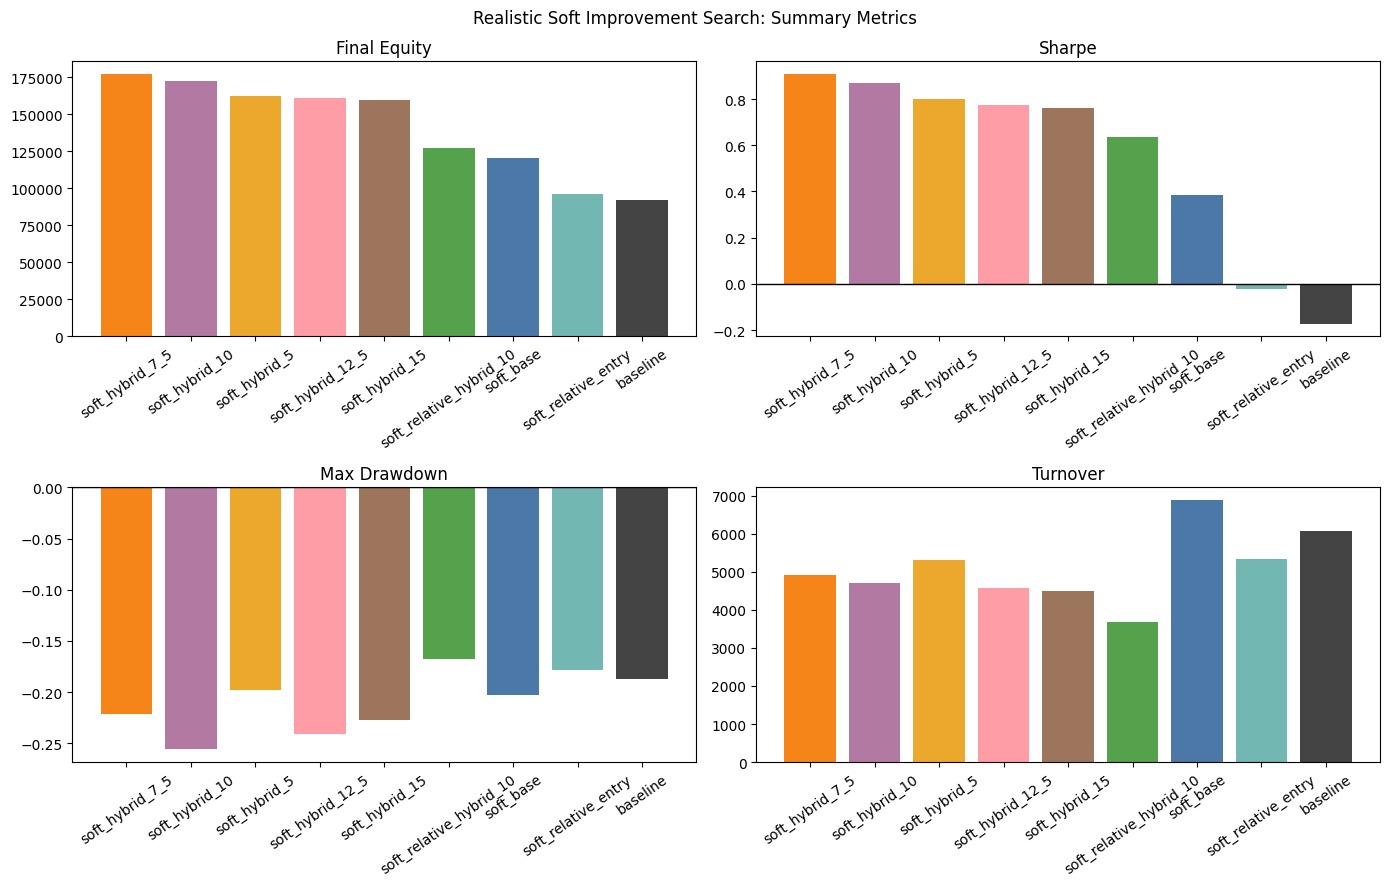

PosixPath('/Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/plots/realistic_soft_summary_metrics.png')

In [3]:
COLORS = {
    'baseline': '#444444',
    'soft_base': '#4C78A8',
    'soft_relative_entry': '#72B7B2',
    'soft_relative_hybrid_10': '#54A24B',
    'soft_hybrid_5': '#ECA82C',
    'soft_hybrid_7_5': '#F58518',
    'soft_hybrid_10': '#B279A2',
    'soft_hybrid_12_5': '#FF9DA6',
    'soft_hybrid_15': '#9D755D',
    'soft_risk_q80_m75': '#BAB0AC',
}

order = summary['method'].tolist()
colors = [COLORS.get(m, '#777777') for m in order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(order, summary['final_equity'], color=colors)
axes[0, 0].set_title('Final Equity')
axes[0, 0].tick_params(axis='x', rotation=35)

axes[0, 1].bar(order, summary['sharpe'], color=colors)
axes[0, 1].set_title('Sharpe')
axes[0, 1].tick_params(axis='x', rotation=35)
axes[0, 1].axhline(0.0, color='black', linewidth=1)

axes[1, 0].bar(order, summary['max_drawdown'], color=colors)
axes[1, 0].set_title('Max Drawdown')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].axhline(0.0, color='black', linewidth=1)

axes[1, 1].bar(order, summary['turnover'], color=colors)
axes[1, 1].set_title('Turnover')
axes[1, 1].tick_params(axis='x', rotation=35)

fig.suptitle('Realistic Soft Improvement Search: Summary Metrics')
fig.tight_layout()
plot_path = PLOTS / 'realistic_soft_summary_metrics.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
plot_path

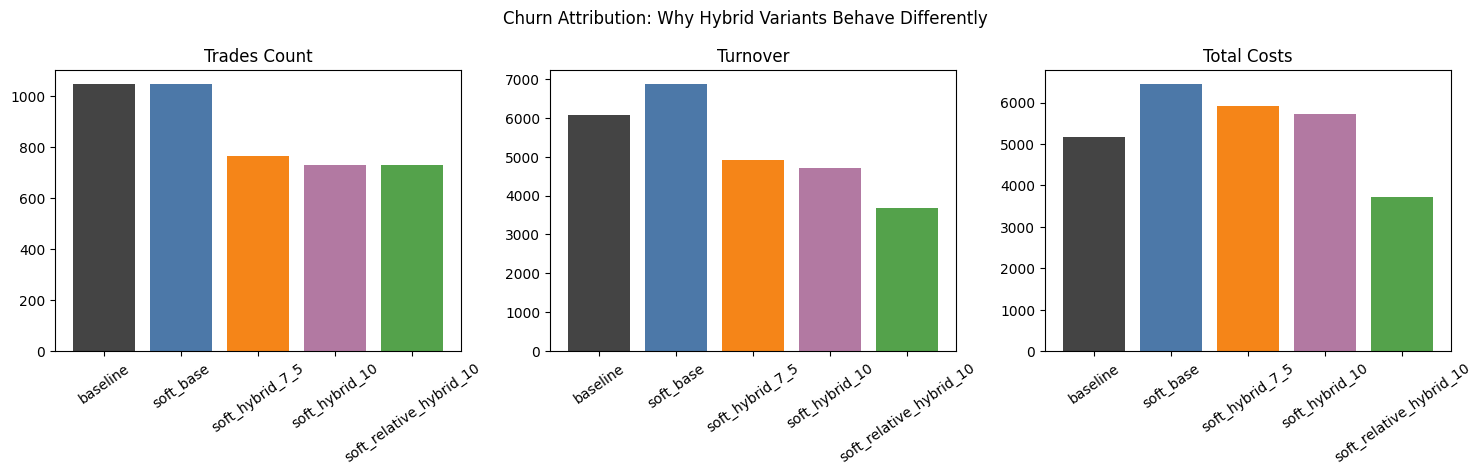

PosixPath('/Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/plots/realistic_soft_churn_attribution.png')

In [4]:
focus = summary.set_index('method').loc[
    ['baseline', 'soft_base', 'soft_hybrid_7_5', 'soft_hybrid_10', 'soft_relative_hybrid_10']
].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

axes[0].bar(focus['method'], focus['trades_count'], color=[COLORS.get(m, '#777777') for m in focus['method']])
axes[0].set_title('Trades Count')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(focus['method'], focus['turnover'], color=[COLORS.get(m, '#777777') for m in focus['method']])
axes[1].set_title('Turnover')
axes[1].tick_params(axis='x', rotation=35)

axes[2].bar(focus['method'], focus['total_costs'], color=[COLORS.get(m, '#777777') for m in focus['method']])
axes[2].set_title('Total Costs')
axes[2].tick_params(axis='x', rotation=35)

fig.suptitle('Churn Attribution: Why Hybrid Variants Behave Differently')
fig.tight_layout()
plot_path = PLOTS / 'realistic_soft_churn_attribution.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
plot_path

## Hybrid Stop Sweep

This plot isolates the hybrid-stop family only. It answers the practical question:

> if catastrophic minute-stop protection is still required, how wide should the catastrophe band be before the stop becomes too loose?

Empirical result from this search:
- `7.5 bps` was the best compromise in this run
- `5 bps` reduced drawdown somewhat relative to `7.5`, but gave up too much Sharpe/equity
- `10+ bps` became looser and started hurting drawdown more than it helped returns


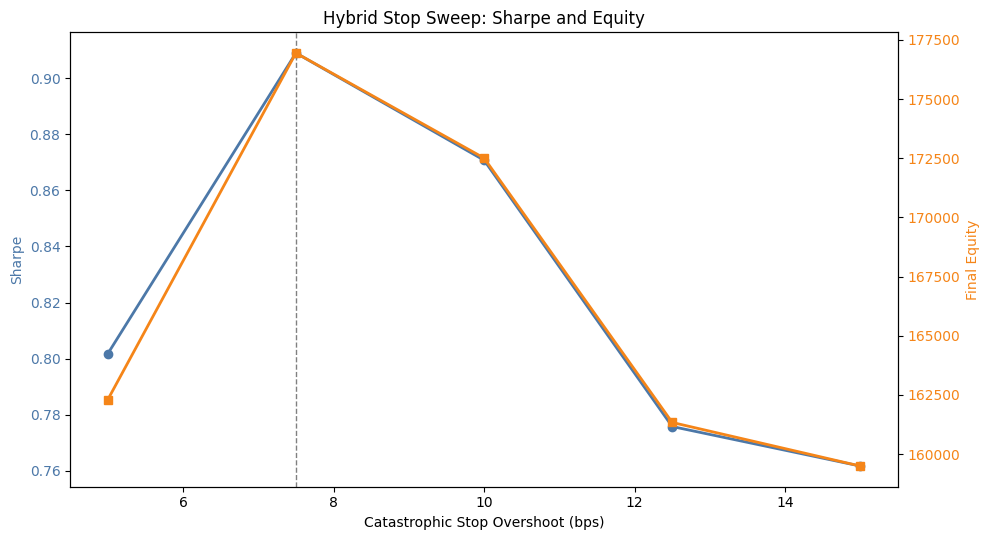

PosixPath('/Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/plots/realistic_soft_hybrid_sweep.png')

In [5]:
hybrid = summary[summary['method'].str.startswith('soft_hybrid_')].copy()
hybrid['stop_bps'] = hybrid['method'].str.replace('soft_hybrid_', '', regex=False).str.replace('_', '.', regex=False).astype(float)
hybrid = hybrid.sort_values('stop_bps')

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax2 = ax1.twinx()

ax1.plot(hybrid['stop_bps'], hybrid['sharpe'], marker='o', linewidth=2, color='#4C78A8', label='Sharpe')
ax1.set_xlabel('Catastrophic Stop Overshoot (bps)')
ax1.set_ylabel('Sharpe', color='#4C78A8')
ax1.tick_params(axis='y', labelcolor='#4C78A8')

ax2.plot(hybrid['stop_bps'], hybrid['final_equity'], marker='s', linewidth=2, color='#F58518', label='Final Equity')
ax2.set_ylabel('Final Equity', color='#F58518')
ax2.tick_params(axis='y', labelcolor='#F58518')

best_row = hybrid.loc[hybrid['sharpe'].idxmax()]
ax1.axvline(best_row['stop_bps'], linestyle='--', color='gray', linewidth=1)
ax1.set_title('Hybrid Stop Sweep: Sharpe and Equity')
fig.tight_layout()
plot_path = PLOTS / 'realistic_soft_hybrid_sweep.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
plot_path

In [6]:
hybrid[['method', 'stop_bps', 'final_equity', 'total_return_pct', 'sharpe', 'max_drawdown', 'trades_count', 'turnover', 'total_costs']]


,method,stop_bps,final_equity,sharpe,max_drawdown,trades_count,turnover,total_costs
2,soft_hybrid_5,5.0,162298.458515,0.801717,-0.198020,825,5298.685501,6150.798
0,soft_hybrid_7_5,7.5,176950.740834,0.909068,-0.221610,765,4917.655661,5927.850
1,soft_hybrid_10,10.0,172510.459918,0.870794,-0.255491,731,4712.452856,5734.566
3,soft_hybrid_12_5,12.5,161335.626858,0.775734,-0.240958,709,4567.851301,5345.235
4,soft_hybrid_15,15.0,159492.327203,0.761620,-0.227517,700,4500.372963,5190.381


## Over-Time Returns

These plots show the actual path through time, not just endpoint metrics.

Why this view matters:
- the summary table tells you who wins at the end
- the time series shows *how* it wins
- it makes it obvious whether a method improves steadily, wins only in one regime, or simply reduces churn

The focus set is:
- `baseline`
- `soft_base`
- `soft_hybrid_7_5`
- `soft_hybrid_10`
- `soft_relative_hybrid_10`


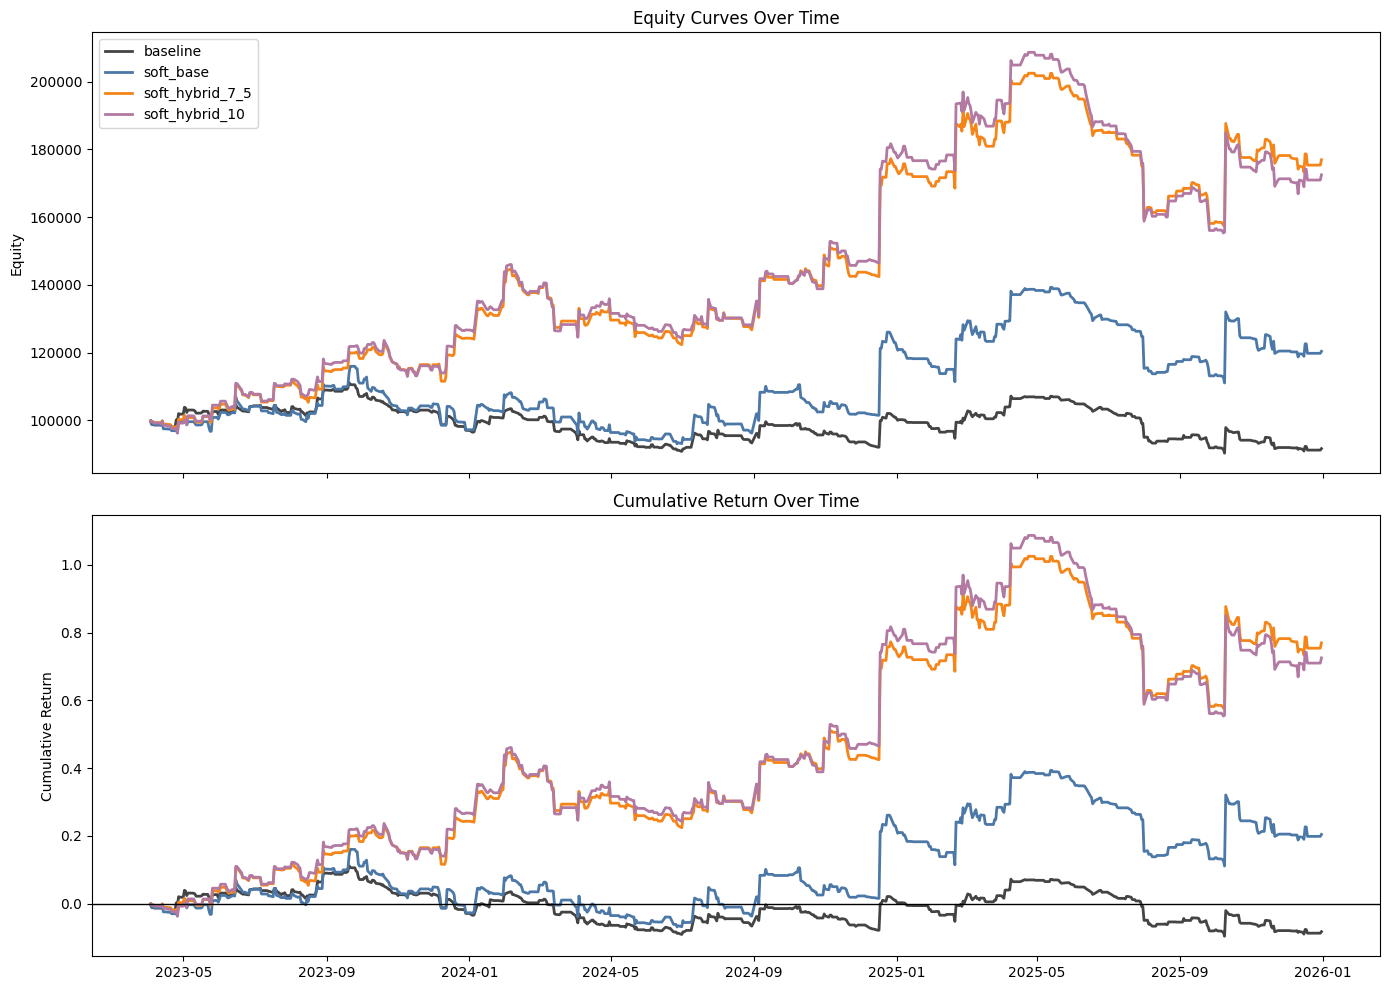

PosixPath('/Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/plots/realistic_soft_equity_and_cum_return.png')

In [7]:
if curve_df.empty:
    raise FileNotFoundError(
        f'No cached curve files found under {CURVES}. Run the cached realistic curve generation first.'
    )

plot_order = [m for m in ['baseline', 'soft_base', 'soft_hybrid_7_5', 'soft_hybrid_10', 'soft_relative_hybrid_10'] if m in set(curve_df['method'])]
plot_df = curve_df[curve_df['method'].isin(plot_order)].copy()
plot_df = plot_df.sort_values(['method', 'date'])
plot_df['cum_return'] = plot_df.groupby('method', sort=False)['daily_return'].transform(lambda s: (1.0 + s).cumprod() - 1.0)
plot_df['rolling_20d_return'] = plot_df.groupby('method', sort=False)['daily_return'].transform(lambda s: (1.0 + s).rolling(20).apply(np.prod, raw=True) - 1.0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for method in plot_order:
    mdf = plot_df[plot_df['method'] == method]
    color = COLORS.get(method, '#777777')
    axes[0].plot(mdf['date'], mdf['equity'], label=method, color=color, linewidth=2)
    axes[1].plot(mdf['date'], mdf['cum_return'], label=method, color=color, linewidth=2)

axes[0].set_title('Equity Curves Over Time')
axes[0].set_ylabel('Equity')
axes[0].legend()
axes[1].set_title('Cumulative Return Over Time')
axes[1].set_ylabel('Cumulative Return')
axes[1].axhline(0.0, color='black', linewidth=1)
fig.tight_layout()
plot_path = PLOTS / 'realistic_soft_equity_and_cum_return.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
plot_path

## Rolling Return View

This plot helps identify whether the winner is just benefiting from one isolated period or whether it keeps a better local return profile through time.


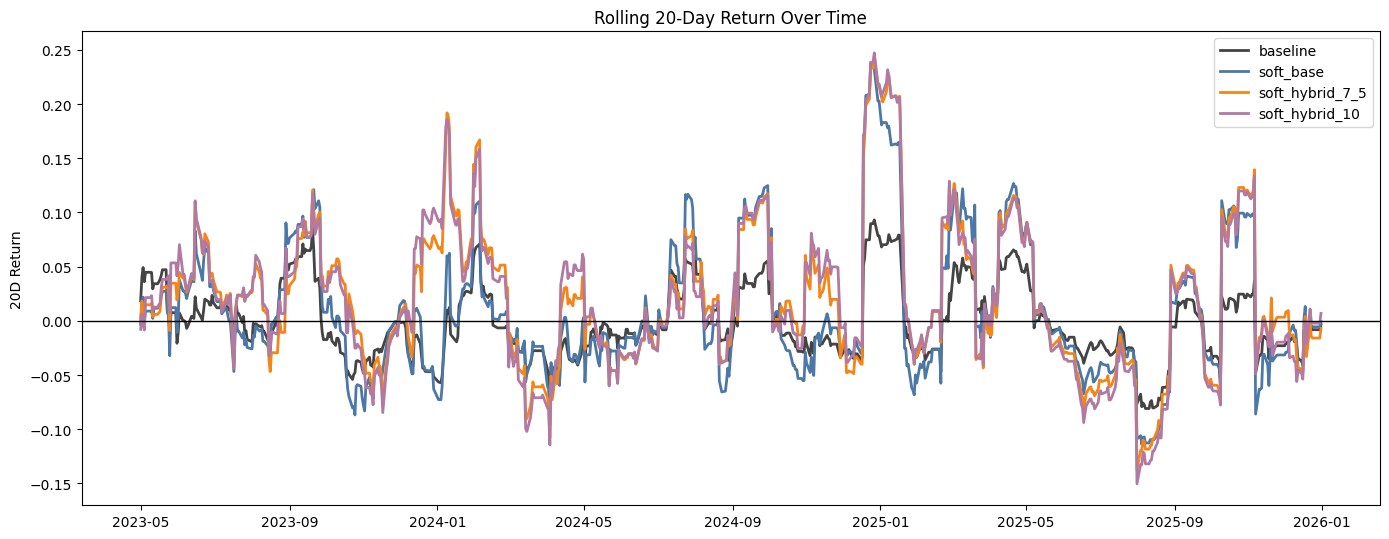

PosixPath('/Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/plots/realistic_soft_rolling_20d_return.png')

In [8]:
fig, ax = plt.subplots(figsize=(14, 5.5))
for method in plot_order:
    mdf = plot_df[plot_df['method'] == method]
    color = COLORS.get(method, '#777777')
    ax.plot(mdf['date'], mdf['rolling_20d_return'], label=method, color=color, linewidth=2)
ax.axhline(0.0, color='black', linewidth=1)
ax.set_title('Rolling 20-Day Return Over Time')
ax.set_ylabel('20D Return')
ax.legend()
fig.tight_layout()
plot_path = PLOTS / 'realistic_soft_rolling_20d_return.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
plot_path

## Why `soft_hybrid_7_5` Is Better

Mechanically, the hybrid stop is better because it changes *how often* the realistic backtest exits for noise.

Before (`soft_base`):
- every minute stop touch could force an exit
- that created many marginal stop-outs
- marginal stop-outs created re-entry churn later in the day
- churn raised turnover and costs and damaged the realized path

After (`soft_hybrid_7_5`):
- minute-level stop monitoring is still present
- but it only exits immediately when the stop breach is meaningfully worse than the stop itself (`7.5 bps` overshoot)
- otherwise the strategy waits until the next decision timestamp and checks the normal stop there

Observed effect in the metrics:
- trades count falls from `1049` to `765`
- turnover falls from `6875.15` to `4917.66`
- costs fall from `6454.17` to `5927.85`
- final equity and Sharpe both improve materially

This is not new alpha. It is a cleaner *realistic execution policy* that preserves more of the alpha already present in the baseline + ML sizing stack.

Tradeoff:
- max drawdown worsens versus `soft_base`
- the exact `7.5 bps` setting should still be treated as selection-sensitive until frozen against a fresh holdout


In [9]:
explain = summary.set_index('method').loc[['baseline', 'soft_base', 'soft_hybrid_7_5']].copy()
explain[['final_equity', 'total_return_pct', 'sharpe', 'max_drawdown', 'trades_count', 'turnover', 'total_costs']]


,final_equity,sharpe,max_drawdown,trades_count,turnover,total_costs
method,,,,,,
baseline,91686.893773,-0.171875,-0.187587,1049,6068.779522,5160.231
soft_base,120396.904439,0.383525,-0.202688,1049,6875.154542,6454.170
soft_hybrid_7_5,176950.740834,0.909068,-0.221610,765,4917.655661,5927.850


In [10]:
out_summary = REPORTS / 'realistic_soft_notebook3_summary.csv'
out_focus = REPORTS / 'realistic_soft_notebook3_focus.csv'
summary.to_csv(out_summary, index=False)
focus.to_csv(out_focus, index=False)
print('Saved:', out_summary)
print('Saved:', out_focus)
print('Loaded curve files from:', CURVES)
print('Saved plots to:', PLOTS)

Saved: /Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/realistic_soft_notebook3_summary.csv
Saved: /Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/realistic_soft_notebook3_focus.csv
Loaded curve files from: /Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/realistic_soft_curves
Saved plots to: /Users/ulianahusak/WUTIS_2026/intraday_momentum_ml/reports/model_selection/plots
